In [11]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


data = fetch_california_housing(as_frame=True)
df = data.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [13]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [14]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


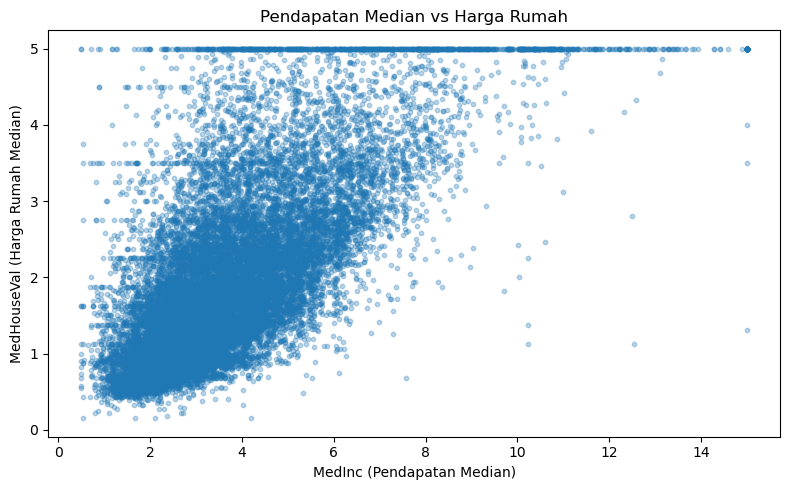

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.3, s=10)
plt.title('Pendapatan Median vs Harga Rumah')
plt.xlabel('MedInc (Pendapatan Median)')
plt.ylabel('MedHouseVal (Harga Rumah Median)')
plt.tight_layout()
plt.show()

Berdasarkan scatter plot, terdapat pola linear positif antara pendapatan median (MedInc) dan harga rumah median (MedHouseVal), artinya semakin tinggi pendapatan median suatu distrik, harga rumah cenderung semakin tinggi. Meskipun demikian, data cukup tersebar dan tidak sempurna linear, menunjukkan bahwa MedInc saja tidak cukup untuk menjelaskan seluruh variasi harga rumah.

In [16]:
X_simple = df[['MedInc']]
y = df['MedHouseVal']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

print('Intercept :', model_simple.intercept_)
print('Koefisien :', model_simple.coef_[0])

Intercept : 0.4445972916907883
Koefisien : 0.41933849393812694


In [17]:
y_pred_s = model_simple.predict(X_test_s)

mae_s  = mean_absolute_error(y_test_s, y_pred_s)
mse_s  = mean_squared_error(y_test_s, y_pred_s)
rmse_s = np.sqrt(mse_s)
r2_s   = r2_score(y_test_s, y_pred_s)

print(f'MAE  : {mae_s:.4f}')
print(f'MSE  : {mse_s:.4f}')
print(f'RMSE : {rmse_s:.4f}')
print(f'R2   : {r2_s:.4f}')

MAE  : 0.6299
MSE  : 0.7091
RMSE : 0.8421
R2   : 0.4589


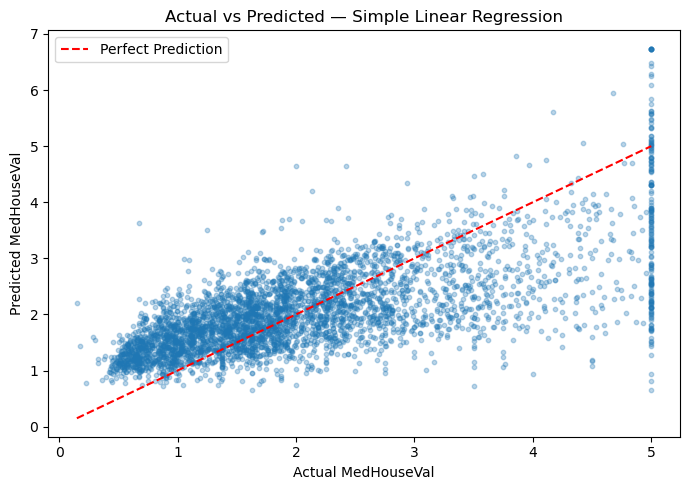

In [18]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_s, y_pred_s, alpha=0.3, s=10)
plt.plot([y_test_s.min(), y_test_s.max()], [y_test_s.min(), y_test_s.max()], 'r--', label='Perfect Prediction')
plt.title('Actual vs Predicted — Simple Linear Regression')
plt.xlabel('Actual MedHouseVal')
plt.ylabel('Predicted MedHouseVal')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
X_multi = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

y_pred_train_m = model_multi.predict(X_train_m)
y_pred_test_m  = model_multi.predict(X_test_m)

print('--- Training Set ---')
print(f'MAE  : {mean_absolute_error(y_train_m, y_pred_train_m):.4f}')
print(f'MSE  : {mean_squared_error(y_train_m, y_pred_train_m):.4f}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_train_m, y_pred_train_m)):.4f}')
print(f'R2   : {r2_score(y_train_m, y_pred_train_m):.4f}')

print()

# Metrik test set
print('--- Test Set ---')
mae_m  = mean_absolute_error(y_test_m, y_pred_test_m)
mse_m  = mean_squared_error(y_test_m, y_pred_test_m)
rmse_m = np.sqrt(mse_m)
r2_m   = r2_score(y_test_m, y_pred_test_m)
print(f'MAE  : {mae_m:.4f}')
print(f'MSE  : {mse_m:.4f}')
print(f'RMSE : {rmse_m:.4f}')
print(f'R2   : {r2_m:.4f}')

--- Training Set ---
MAE  : 0.5286
MSE  : 0.5179
RMSE : 0.7197
R2   : 0.6126

--- Test Set ---
MAE  : 0.5332
MSE  : 0.5559
RMSE : 0.7456
R2   : 0.5758




Berdasarkan perbandingan R2 Train dan R2 Test pada Multiple Linear Regression, kedua nilai relatif berdekatan (selisih kecil), sehingga model tergolong *good fit*. Model tidak mengalami overfitting karena R2 Test tidak jauh lebih rendah dari R2 Train, dan tidak underfitting karena R2 sudah cukup di atas 0.5. Nilai R2 sekitar 0.60 menunjukkan model mampu menjelaskan sekitar 60% variansi harga rumah menggunakan semua fitur yang tersedia.

In [20]:
# Hitung MAPE untuk Multiple Linear Regression pada test set
mape_m = np.mean(np.abs((y_test_m.values - y_pred_test_m) / y_test_m.values)) * 100
print(f'MAPE Multiple Linear Regression (Test Set): {mape_m:.2f}%')

MAPE Multiple Linear Regression (Test Set): 31.95%



Nilai MAPE yang dihasilkan menunjukkan rata-rata persentase kesalahan prediksi model terhadap harga aktual. Jika misalnya MAPE bernilai 30%, artinya model rata-rata salah memprediksi harga sebesar 30% dari harga sebenarnya, yang dalam konteks bisnis properti berarti estimasi harga bisa meleset cukup jauh sehingga kurang dapat diandalkan sebagai satu-satunya acuan keputusan harga jual atau beli properti.


Beberapa langkah yang dapat dilakukan untuk meningkatkan performa model antara lain: menambahkan fitur baru yang lebih relevan seperti jarak ke pusat kota atau kondisi infrastruktur, menerapkan feature engineering seperti transformasi logaritmik pada fitur yang skewed, atau menggunakan model yang lebih kompleks seperti Random Forest atau Gradient Boosting yang mampu menangkap hubungan non-linear antar fitur.